In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [240]:
df = pd.read_csv(r'E:\competition\COmsic Classifier IIT Roorkie\Cosmic-Classifier\data\thermoracleTrain.csv')
df = df.dropna(subset=['Prediction'])
df.sample(5)

,Atmospheric Density,Surface Temperature,Gravity,Water Content,Mineral Abundance,Orbital Period,Proximity to Star,Magnetic Field Strength,Radiation Levels,Atmospheric Composition Index,Prediction
40606,0.322104,1.775116,-2.558860,1.367352,0.903154,-0.616450,-1.474862,Category_12,Category_15,0.863249,4.0
17663,-0.524710,-0.007627,0.735941,1.302609,-1.669052,-0.434585,-2.294273,Category_10,Category_7,-0.501070,2.0
43488,4.507172,-2.922839,-3.011899,-1.035054,0.705303,-0.695249,-0.444598,Category_9,Category_8,-2.603826,5.0
21415,2.352384,-4.123935,0.762668,0.668838,-0.447669,-0.641423,2.394635,Category_15,Category_10,-0.960325,3.0
15964,-3.952161,-0.684478,-0.102120,0.044179,-1.704229,-0.658122,1.514726,Category_8,Category_9,0.198753,1.0


In [241]:
df.isnull().sum()

Atmospheric Density              2842
Surface Temperature              2896
Gravity                          2826
Water Content                    2936
Mineral Abundance                2784
Orbital Period                   2855
Proximity to Star                2786
Magnetic Field Strength          2941
Radiation Levels                 2859
Atmospheric Composition Index    2795
Prediction                          0
dtype: int64

In [242]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 56961 entries, 0 to 59999
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Atmospheric Density            54119 non-null  float64
 1   Surface Temperature            54065 non-null  float64
 2   Gravity                        54135 non-null  float64
 3   Water Content                  54025 non-null  float64
 4   Mineral Abundance              54177 non-null  float64
 5   Orbital Period                 54106 non-null  float64
 6   Proximity to Star              54175 non-null  float64
 7   Magnetic Field Strength        54020 non-null  object 
 8   Radiation Levels               54102 non-null  object 
 9   Atmospheric Composition Index  54166 non-null  float64
 10  Prediction                     56961 non-null  float64
dtypes: float64(9), object(2)
memory usage: 5.2+ MB


In [243]:
columns =['Atmospheric Density',
'Gravity',
'Water Content',
'Mineral Abundance',
'Orbital Period',
'Proximity to Star',
'Atmospheric Composition Index',
'Prediction']


df.reset_index(drop=True, inplace=True)

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Create a boolean mask for filtering out the outliers as some of the indexes are missing
    mask = (df[col] >= lower_bound) & (df[col] <= upper_bound)
    df = df[mask]


df.reset_index(drop=True, inplace=True)

In [244]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(df.drop(columns=['Prediction'], axis=1), df['Prediction'], test_size=0.2, random_state=42)

In [245]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(30519, 10)
(7630, 10)
(30519,)
(7630,)


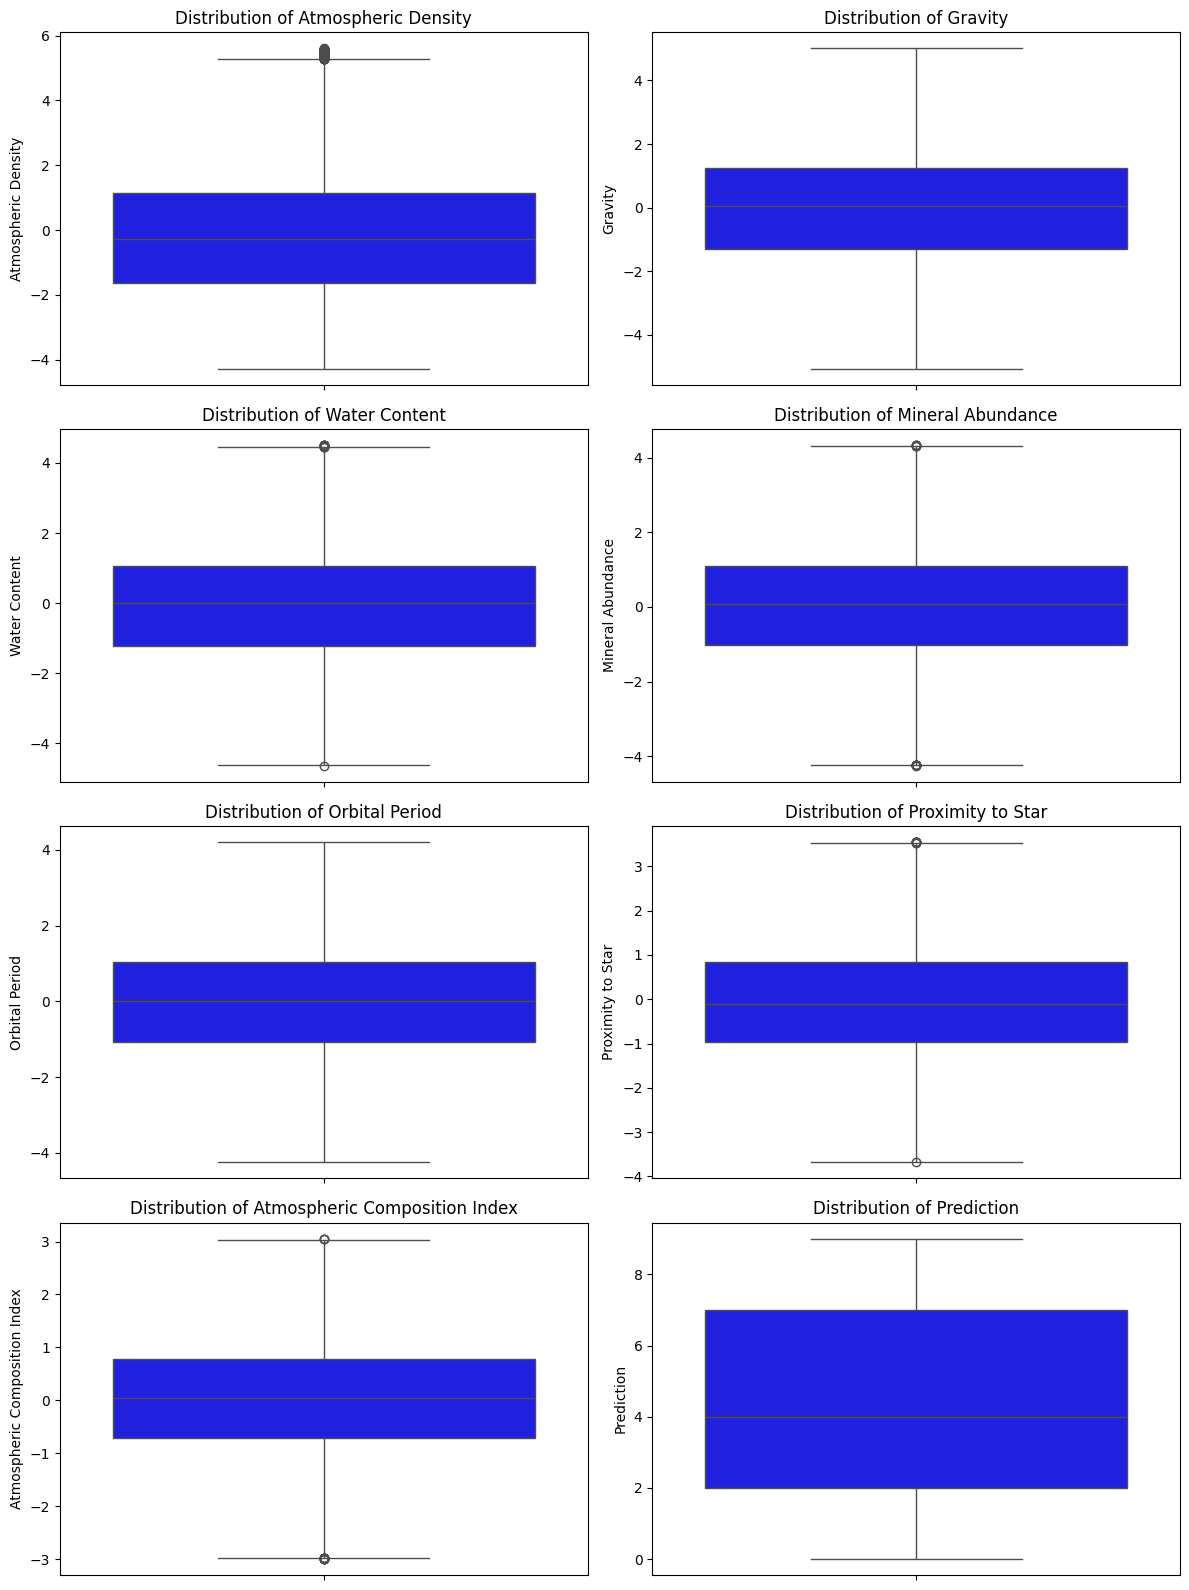

In [246]:
import math

columns =['Atmospheric Density',
'Gravity',
'Water Content',
'Mineral Abundance',
'Orbital Period',
'Proximity to Star',
'Atmospheric Composition Index',
'Prediction']

num_colss = 2  
num_rowss = math.ceil(len(columns) / num_colss)

fig, axes = plt.subplots(num_rowss, num_colss, figsize=(12, num_rowss * 4))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(df[col],  color='blue', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Impute values

In [247]:
columns = ['Atmospheric Density', 'Surface Temperature', 'Gravity',
           'Water Content', 'Mineral Abundance', 'Orbital Period',
           'Proximity to Star', 'Atmospheric Composition Index']

In [248]:
#imputing using median
from sklearn.impute import SimpleImputer
# si_median = SimpleImputer(strategy='median')

from sklearn.impute import KNNImputer
knn = KNNImputer()
x_train[columns] = knn.fit_transform(x_train[columns])
x_test[columns] = knn.transform(x_test[columns])


# df[columns] = si_median.fit_transform(df[columns])

In [249]:
freq_encode_cols = ['Radiation Levels' , 'Magnetic Field Strength']

for col in freq_encode_cols:
    freq_map = x_train[col].value_counts().to_dict()
    x_train[col] = x_train[col].map(freq_map)


si_mode = SimpleImputer(strategy='most_frequent')
x_train['Magnetic Field Strength'] = si_mode.fit_transform(x_train[['Magnetic Field Strength']])
x_train['Radiation Levels'] = si_mode.fit_transform(x_train[['Radiation Levels']])



freq_encode_cols = ['Radiation Levels' , 'Magnetic Field Strength']

for col in freq_encode_cols:
    freq_map = x_test[col].value_counts().to_dict()
    x_test[col] = x_test[col].map(freq_map)


si_mode = SimpleImputer(strategy='most_frequent')
x_test['Magnetic Field Strength'] = si_mode.fit_transform(x_test[['Magnetic Field Strength']])
x_test['Radiation Levels'] = si_mode.fit_transform(x_test[['Radiation Levels']])

In [250]:
x_train.isnull().sum()

Atmospheric Density              0
Surface Temperature              0
Gravity                          0
Water Content                    0
Mineral Abundance                0
Orbital Period                   0
Proximity to Star                0
Magnetic Field Strength          0
Radiation Levels                 0
Atmospheric Composition Index    0
dtype: int64

Remove outliars

In [251]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(30519, 10)
(7630, 10)
(30519,)
(7630,)


Removing Skewness

In [252]:
from sklearn.preprocessing import PowerTransformer
columns = ['Atmospheric Density', 'Surface Temperature', 'Gravity',
           'Water Content', 'Mineral Abundance', 'Orbital Period',
           'Proximity to Star', 'Atmospheric Composition Index']

pt = PowerTransformer(method='yeo-johnson')
for col in columns:
    x_train[col] = pt.fit_transform(x_train[[col]])


pt = PowerTransformer(method='yeo-johnson')
for col in columns:
    x_test[col] = pt.fit_transform(x_test[[col]])

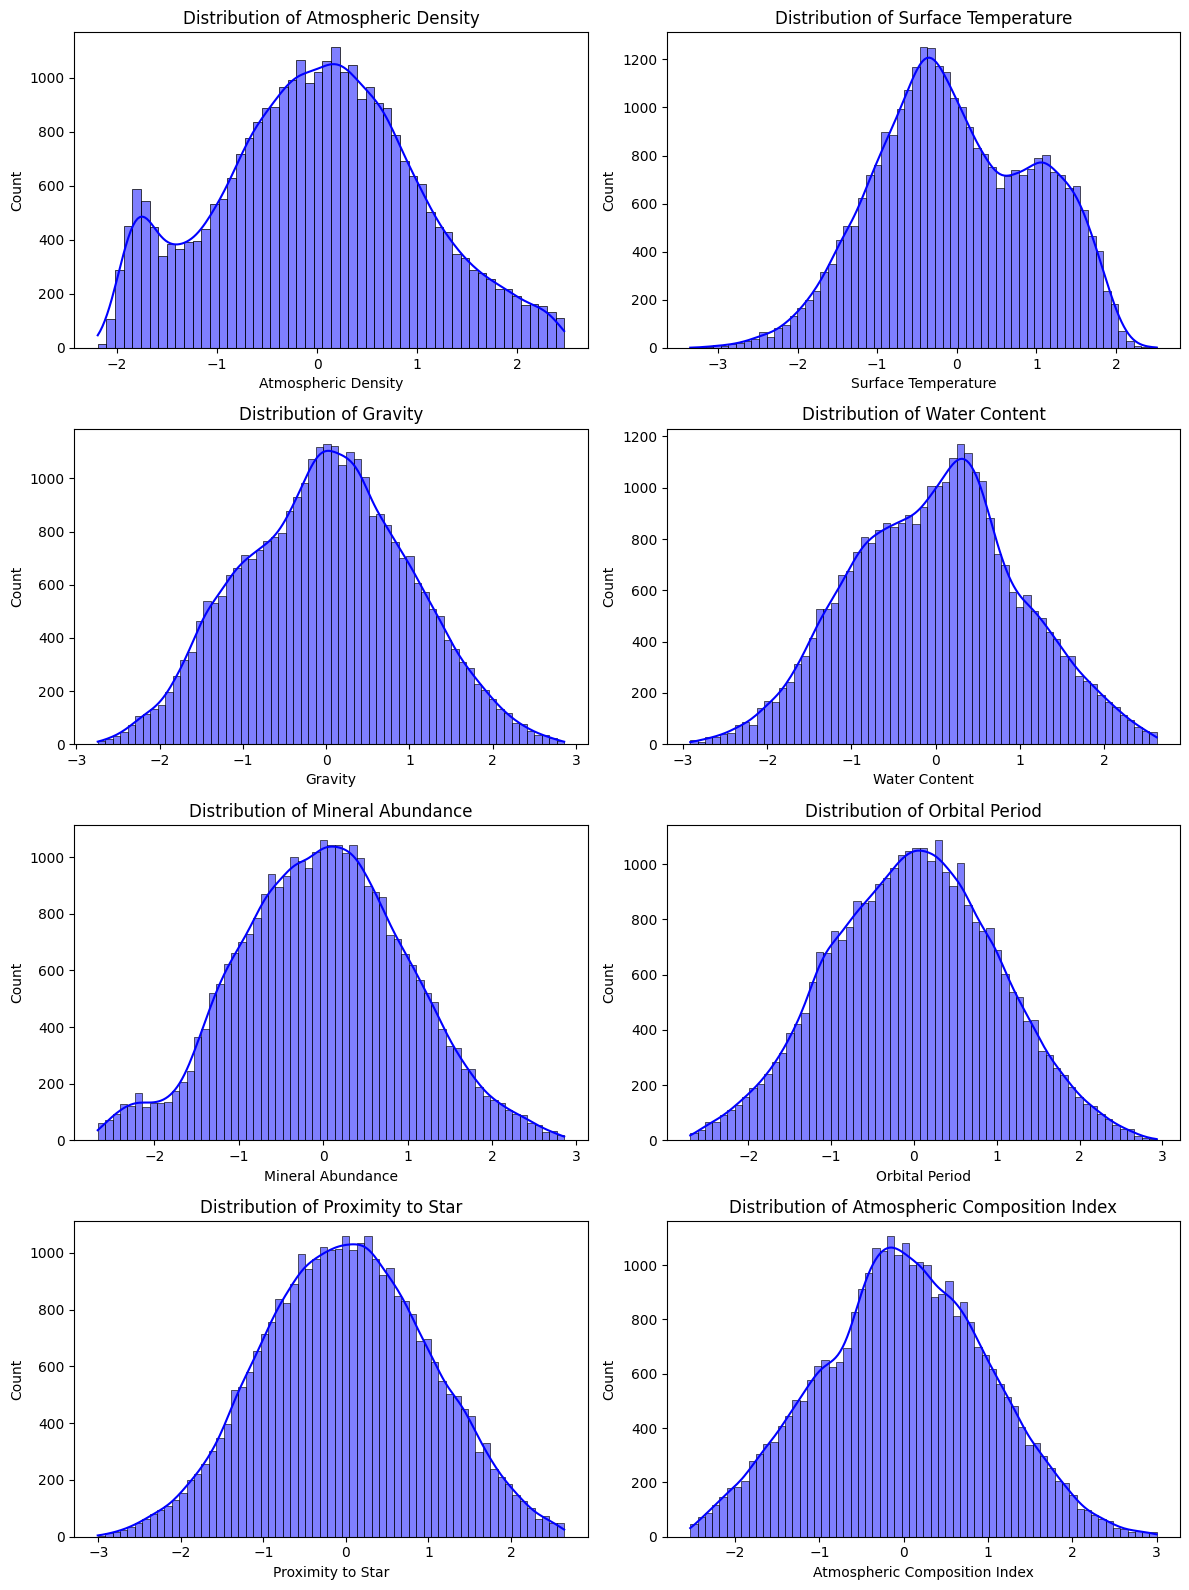

In [253]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

columns = ['Atmospheric Density', 'Surface Temperature', 'Gravity',
           'Water Content', 'Mineral Abundance', 'Orbital Period',
           'Proximity to Star', 'Atmospheric Composition Index']

num_colss = 2  
num_rowss = math.ceil(len(columns) / num_colss)

fig, axes = plt.subplots(num_rowss, num_colss, figsize=(12, num_rowss * 4))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(x_train[col], kde=True, color='blue', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [254]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()

# Store original categorical columns
train_magnetic = x_train['Magnetic Field Strength'].copy()
train_radiation = x_train['Radiation Levels'].copy()
test_magnetic = x_test['Magnetic Field Strength'].copy()
test_radiation = x_test['Radiation Levels'].copy()

# Transform numerical columns
x_train_scaled = mms.fit_transform(x_train[columns])
x_test_scaled = mms.transform(x_test[columns])

# Convert back to DataFrame with proper indices
x_train = pd.DataFrame(x_train_scaled, columns=columns, index=train_magnetic.index)
x_test = pd.DataFrame(x_test_scaled, columns=columns, index=test_magnetic.index)

# Add back categorical columns
x_train['Magnetic Field Strength'] = train_magnetic
x_train['Radiation Levels'] = train_radiation
x_test['Magnetic Field Strength'] = test_magnetic
x_test['Radiation Levels'] = test_radiation

# Display results
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
x_train.head()

Training data shape: (30519, 10)
Test data shape: (7630, 10)


,Atmospheric Density,Surface Temperature,Gravity,Water Content,Mineral Abundance,Orbital Period,Proximity to Star,Atmospheric Composition Index,Magnetic Field Strength,Radiation Levels
18686,0.475847,0.403492,0.826298,0.466354,0.614162,0.498747,0.457757,0.410840,1731.0,4778.0
17048,0.597779,0.322306,0.233492,0.422281,0.789569,0.592874,0.560906,0.290249,4065.0,4184.0
15423,0.618510,0.492019,0.806838,0.606099,0.421897,0.478391,0.081640,0.361742,1731.0,818.0
11112,0.227952,0.473725,0.525513,0.666657,0.365770,0.674199,0.104015,0.511876,4065.0,5009.0
22818,0.371492,0.482415,0.652040,0.566294,0.313799,0.258423,0.396825,0.508253,4661.0,5009.0


Encoding Categorical Features

In [255]:
freq_encode_cols = ['Radiation Levels' , 'Magnetic Field Strength']

for col in freq_encode_cols:
    freq_map = x_train[col].value_counts().to_dict()
    x_train[col] = x_train[col].map(freq_map)


si_mode = SimpleImputer(strategy='most_frequent')
x_train['Magnetic Field Strength'] = si_mode.fit_transform(x_train[['Magnetic Field Strength']])
x_train['Radiation Levels'] = si_mode.fit_transform(x_train[['Radiation Levels']])


for col in freq_encode_cols:
    freq_map = x_test[col].value_counts().to_dict()
    x_test[col] = x_test[col].map(freq_map)


si_mode = SimpleImputer(strategy='most_frequent')
x_test['Magnetic Field Strength'] = si_mode.fit_transform(x_test[['Magnetic Field Strength']])
x_test['Radiation Levels'] = si_mode.fit_transform(x_test[['Radiation Levels']])

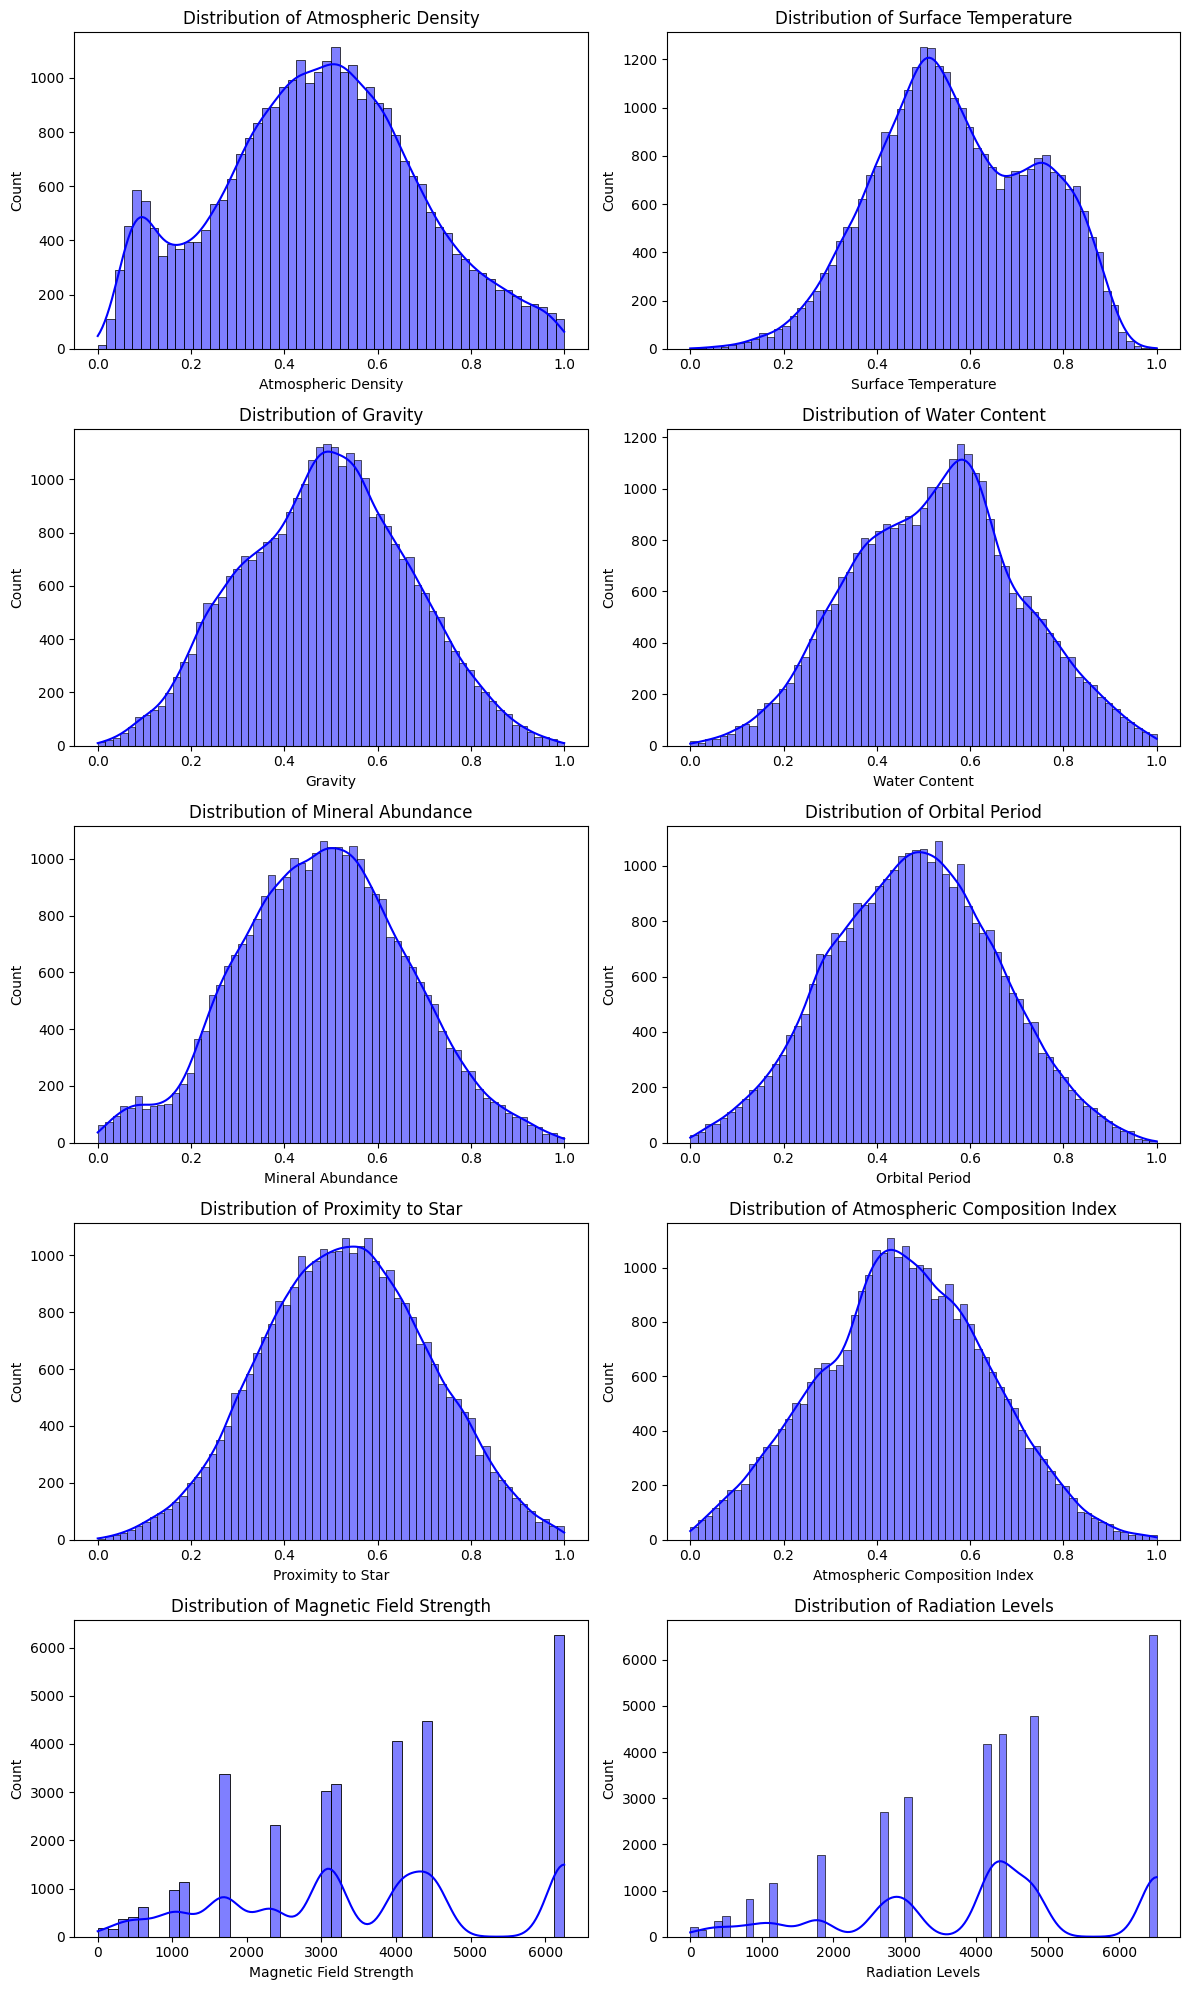

In [256]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

columns = ['Atmospheric Density', 'Surface Temperature', 'Gravity',
           'Water Content', 'Mineral Abundance', 'Orbital Period',
           'Proximity to Star', 'Atmospheric Composition Index', 'Magnetic Field Strength', 'Radiation Levels']

num_colss = 2  
num_rowss = math.ceil(len(columns) / num_colss)

fig, axes = plt.subplots(num_rowss, num_colss, figsize=(12, num_rowss * 4))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(x_train[col], kde=True, color='blue', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [257]:
x_train['atmospheric pressure'] = x_train['Gravity']*x_train['Atmospheric Density']
x_train['Energy Recieved'] = x_train['Proximity to Star']*x_train['Orbital Period']
x_train['Water state'] = x_train['Water Content']*x_train['Surface Temperature']

x_test['atmospheric pressure'] = x_test['Gravity']*x_test['Atmospheric Density']
x_test['Energy Recieved'] = x_test['Proximity to Star']*x_test['Orbital Period']
x_test['Water state'] = x_test['Water Content']*x_test['Surface Temperature']

In [258]:
x_train['Thermal Efficiency'] = x_train['Surface Temperature']/x_train['Proximity to Star']
x_train['Atmospheric Retention'] = x_train['Atmospheric Density']/x_train['Gravity']
x_train['Water phase indicator'] = x_train['Water Content']/x_train['Surface Temperature']

x_test['Thermal Efficiency'] = x_test['Surface Temperature']/x_test['Proximity to Star']
x_test['Atmospheric Retention'] = x_test['Atmospheric Density']/x_test['Gravity']
x_test['Water phase indicator'] = x_test['Water Content']/x_test['Surface Temperature']


In [259]:
x_train['Surface Temperature Polynomial'] = x_train['Surface Temperature']**2
x_train['Gravity Polynomial'] = x_train['Gravity']**2
x_train['Proximity to Star Polynomial'] = x_train['Proximity to Star']**2

x_test['Surface Temperature Polynomial'] = x_test['Surface Temperature']**2
x_test['Gravity Polynomial'] = x_test['Gravity']**2
x_test['Proximity to Star Polynomial'] = x_test['Proximity to Star']**2

In [260]:
x_train['rf1'] = x_train['Water Content']/x_train['Mineral Abundance']
x_train['rf2'] = x_train['Atmospheric Density']/x_train['Surface Temperature']
x_train['rf3'] = x_train['Gravity']/x_train['Orbital Period']

x_test['rf1'] = x_test['Water Content']/x_test['Mineral Abundance']
x_test['rf2'] = x_test['Atmospheric Density']/x_test['Surface Temperature']
x_test['rf3'] = x_test['Gravity']/x_test['Orbital Period']

In [261]:
x_train.sample(5)

,Atmospheric Density,Surface Temperature,Gravity,Water Content,Mineral Abundance,Orbital Period,Proximity to Star,Atmospheric Composition Index,Magnetic Field Strength,Radiation Levels,...,Water state,Thermal Efficiency,Atmospheric Retention,Water phase indicator,Surface Temperature Polynomial,Gravity Polynomial,Proximity to Star Polynomial,rf1,rf2,rf3
24024,0.596583,0.305034,0.236496,0.501563,0.882942,0.367874,0.547052,0.408597,6253,4184,...,0.152994,0.557595,2.522595,1.644287,0.093046,0.055930,0.299266,0.568060,1.955793,0.642872
23366,0.387055,0.454224,0.600984,0.621074,0.577528,0.188584,0.464660,0.583903,2316,6526,...,0.282107,0.977540,0.644035,1.367329,0.206320,0.361182,0.215909,1.075400,0.852123,3.186820
1742,0.532028,0.783535,0.603615,0.358903,0.514003,0.471582,0.583516,0.363815,3021,4184,...,0.281213,1.342783,0.881403,0.458057,0.613927,0.364351,0.340490,0.698251,0.679010,1.279979
34215,0.111755,0.289148,0.543739,0.634296,0.366800,0.591780,0.481060,0.553762,6253,3033,...,0.183405,0.601064,0.205531,2.193675,0.083606,0.295652,0.231418,1.729269,0.386498,0.918819
19106,0.290602,0.511953,0.194589,0.538695,0.339465,0.268767,0.461188,0.572995,3162,4184,...,0.275787,1.110074,1.493415,1.052236,0.262096,0.037865,0.212695,1.586894,0.567635,0.724006


In [262]:
mask_train = np.isfinite(x_train).all(axis=1)
x_train = x_train[mask_train].reset_index(drop=True)
y_train = y_train[mask_train].reset_index(drop=True)

# For the testing set
mask_test = np.isfinite(x_test).all(axis=1)
x_test = x_test[mask_test].reset_index(drop=True)
y_test = y_test[mask_test].reset_index(drop=True)

In [263]:
columns_cf = ['atmospheric pressure','Energy Recieved', 'Water state',
              'Thermal Efficiency','Atmospheric Retention','Water phase indicator',
              'Surface Temperature Polynomial','Gravity Polynomial','Proximity to Star Polynomial',
              'rf1','rf2','rf3']

columns_cf = columns + columns_cf

In [264]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()

# Scale numerical columns
x_train_scaled = mms.fit_transform(x_train[columns_cf])
x_test_scaled = mms.transform(x_test[columns_cf])

# Convert back to DataFrame
x_train = pd.DataFrame(x_train_scaled, columns=columns_cf, index=x_train.index)
x_test = pd.DataFrame(x_test_scaled, columns=columns_cf, index=x_test.index)

# Display results
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
x_train.head()

Training data shape: (30514, 22)
Test data shape: (7630, 22)


,Atmospheric Density,Surface Temperature,Gravity,Water Content,Mineral Abundance,Orbital Period,Proximity to Star,Atmospheric Composition Index,Magnetic Field Strength,Radiation Levels,...,Water state,Thermal Efficiency,Atmospheric Retention,Water phase indicator,Surface Temperature Polynomial,Gravity Polynomial,Proximity to Star Polynomial,rf1,rf2,rf3
0,0.475847,0.396163,0.826234,0.466354,0.613967,0.498603,0.455680,0.410840,0.276711,0.732107,...,0.227838,0.004283,0.000390,0.027926,0.162682,0.682768,0.209530,0.001181,0.019064,0.000798
1,0.597779,0.313979,0.233211,0.422281,0.789462,0.592758,0.559225,0.290249,0.650032,0.641073,...,0.164795,0.002764,0.001735,0.031656,0.103749,0.054519,0.314605,0.000832,0.029982,0.000189
2,0.618510,0.485778,0.806767,0.606099,0.421605,0.478242,0.078124,0.361742,0.276711,0.125211,...,0.361078,0.029757,0.000519,0.029763,0.241971,0.650988,0.006651,0.002235,0.020321,0.000812
3,0.227952,0.467259,0.525339,0.666657,0.365450,0.674106,0.100585,0.511876,0.650032,1.000000,...,0.382388,0.022468,0.000294,0.034002,0.224301,0.276164,0.010805,0.002835,0.007779,0.000375
4,0.371492,0.476056,0.651912,0.566294,0.313452,0.258211,0.394515,0.508253,1.000000,1.000000,...,0.330779,0.005938,0.000386,0.028362,0.232612,0.425156,0.157458,0.002807,0.012449,0.001216


xgboost

In [265]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score , recall_score , f1_score
from sklearn.model_selection import cross_val_score
from bayes_opt import BayesianOptimization
import xgboost as xgb


In [266]:
print(x_train.shape)
print(y_train.shape)

(30514, 22)
(30514,)


In [267]:
y_train.sample(10)

6008     5.0
9794     3.0
19133    1.0
6195     1.0
5890     7.0
28717    1.0
23842    8.0
18576    7.0
27419    4.0
8759     7.0
Name: Prediction, dtype: float64

In [268]:
def xgb_csv(max_depth, learning_rate, n_estimators, gamma, min_child_weight, subsample, colsample_bytree):
    params = {
        'max_depth': int(max_depth),
        'learning_rate': learning_rate,
        'n_estimators': int(n_estimators),
        'gamma': gamma,
        'min_child_weight': min_child_weight,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'objective': 'multi:softmax', 
        'num_class': 10,  
        'eval_metric': ['mlogloss', 'merror'] 
    }

    cv_results = cross_val_score(
        xgb.XGBClassifier(**params),
        x_train, y_train,
        scoring='accuracy',
        cv=5
    )

    return cv_results.mean()

In [269]:
pbounds = {
    'max_depth': (3, 12),        
    'learning_rate': (0.01, 0.1), 
    'n_estimators': (100, 1000),  
    'gamma': (0, 5),              
    'min_child_weight': (1, 10),  
    'subsample': (0.6, 1),        
    'colsample_bytree': (0.6, 1)  
}

optimizer = BayesianOptimization(
    f=xgb_csv,
    pbounds=pbounds,
    random_state=42,
    verbose=2  
)

In [270]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(30514, 22)
(7630, 22)
(30514,)
(7630,)


In [271]:
import numpy as np

# Check for infinite values
print(np.isinf(x_train).sum())

# Check for very large values
print(np.max(x_train))

Atmospheric Density               0
Surface Temperature               0
Gravity                           0
Water Content                     0
Mineral Abundance                 0
Orbital Period                    0
Proximity to Star                 0
Atmospheric Composition Index     0
Magnetic Field Strength           0
Radiation Levels                  0
atmospheric pressure              0
Energy Recieved                   0
Water state                       0
Thermal Efficiency                0
Atmospheric Retention             0
Water phase indicator             0
Surface Temperature Polynomial    0
Gravity Polynomial                0
Proximity to Star Polynomial      0
rf1                               0
rf2                               0
rf3                               0
dtype: int64
1.0


In [272]:
optimizer.maximize(
    init_points = 10,
    n_iter = 15
)

print(optimizer.max)

|   iter    |  target   | colsam... |   gamma   | learni... | max_depth | min_ch... | n_esti... | subsample |
-------------------------------------------------------------------------------------------------------------
| 1         | 0.8696    | 0.7498    | 4.754     | 0.07588   | 8.388     | 2.404     | 240.4     | 0.6232    |
| 2         | 0.8762    | 0.9465    | 3.006     | 0.07373   | 3.185     | 9.729     | 849.2     | 0.6849    |
| 3         | 0.892     | 0.6727    | 0.917     | 0.03738   | 7.723     | 4.888     | 362.1     | 0.8447    |
| 4         | 0.8865    | 0.6558    | 1.461     | 0.04297   | 7.105     | 8.067     | 279.7     | 0.8057    |
| 5         | 0.8961    | 0.837     | 0.2323    | 0.06468   | 4.535     | 1.585     | 954.0     | 0.9863    |
| 6         | 0.8726    | 0.9234    | 1.523     | 0.01879   | 9.158     | 4.961     | 209.8     | 0.7981    |
| 7         | 0.8723    | 0.6138    | 4.547     | 0.03329   | 8.963     | 3.805     | 568.1     | 0.8187    |
| 8       

In [273]:
from sklearn.metrics import accuracy_score , classification_report

In [276]:
model = xgb.XGBClassifier(
        max_depth=int(4.534717113185623),
        learning_rate=0.06467903667112945,
        n_estimators=int(953.9969835279999),
        gamma=0.23225206359998862,
        min_child_weight=1.5854643368675156,
        subsample=0.9862528132298237,
        colsample_bytree=0.836965827544817,
        objective='multi:softmax', 
        num_class=10,  
        eval_metric=[ 'merror']
)

model.fit(x_train , y_train)
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test , y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.8287


In [277]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

         0.0       0.90      0.92      0.91       627
         1.0       0.95      0.98      0.97       877
         2.0       0.90      0.86      0.88       775
         3.0       0.63      0.79      0.70       786
         4.0       0.76      0.87      0.81       774
         5.0       0.77      0.82      0.80       723
         6.0       0.93      0.92      0.92       749
         7.0       0.87      0.93      0.90       784
         8.0       0.74      0.55      0.63       742
         9.0       0.87      0.63      0.73       793

    accuracy                           0.83      7630
   macro avg       0.83      0.83      0.83      7630
weighted avg       0.83      0.83      0.83      7630



C:\Users\Shiva\AppData\Roaming\Python\Python310\site-packages\xgboost\core.py:158: UserWarning: [01:23:03] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
C:\Users\Shiva\AppData\Roaming\Python\Python310\site-packages\xgboost\core.py:158: UserWarning: [01:23:03] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[0]	validation_0-merror:0.19168	validation_0-mlogloss:1.46274	validation_1-merror:0.24482	validation_1-mlogloss:1.51181
[1]	validation_0-merror:0.16763	validation_0-mlogloss:1.16713	validation_1-merror:0.22477	validation_1-mlogloss:1.25249
[2]	validation_0-merror:0.15642	validation_0-mlogloss:0.97465	validation_1-merror:0.21324	validation_1-mlogloss:1.08379
[3]	validation_0-merror:0.14793	validation_0-mlogloss:0.83751	validation_1-merror:0.20708	validation_1-mlogloss:0.95869
[4]	validation_0-merror:0.14095	validation_0-mlogloss:0.73393	validation_1-merror:0.20079	validation_1-mlogloss:0.87606
[5]	validation_0-merror:0.13456	validation_0-mlogloss:0.65433	validation_1-merror:0.19423	validation_1-mlogloss:0.80502
[6]	validation_0-merror:0.12948	validation_0-mlogloss:0.58926	validation_1-merror:0.19332	validation_1-mlogloss:0.74947
[7]	validation_0-merror:0.12434	validation_0-mlogloss:0.53686	validation_1-merror:0.19279	validation_1-mlogloss:0.70719
[8]	validation_0-merror:0.11965	validati

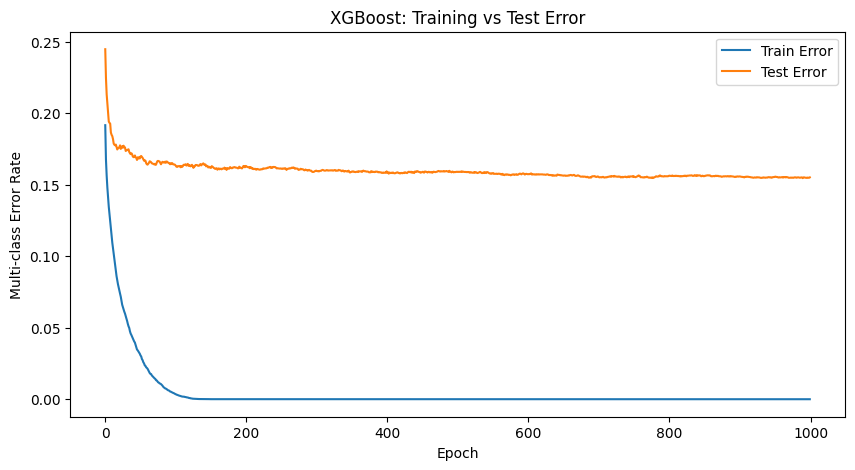

In [278]:
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml



# Define evaluation set
eval_set = [(x_train, y_train), (x_test, y_test)]

# Train the model
modelxgb = xgb.XGBClassifier(
    n_estimators=1000,  # Increase the number of boosting rounds
    eval_metric=['merror', 'mlogloss'],
    use_label_encoder=False,
    objective='multi:softmax',
    num_class=10,
    tree_method='gpu_hist'  # Enable GPU acceleration
)

modelxgb.fit(
    x_train, 
    y_train,
    eval_set=eval_set,
    verbose=True
)

# Retrieve evaluation results
results = modelxgb.evals_result()
epochs = len(results['validation_0']['merror'])  # Changed 'error' to 'merror'
x_axis = range(epochs)

# Plot training and test error
plt.figure(figsize=(10, 5))
plt.plot(x_axis, results['validation_0']['merror'], label='Train Error')
plt.plot(x_axis, results['validation_1']['merror'], label='Test Error')
plt.xlabel('Epoch')
plt.ylabel('Multi-class Error Rate')
plt.title('XGBoost: Training vs Test Error')
plt.legend()
plt.show()